# Tree-type-specific sun–shade linear spectral unmixing

Standalone workflow for an ENVI hyperspectral image (`.bsq` + `.hdr`).

The workflow uses **NDCSI-based automatic endmember selection** and **tree-type-specific two-endmember linear spectral unmixing**:

1. read wavelengths and reflectance data;
2. use mapped broadleaf and conifer polygons as the two analysis domains and calculate NDVI;
3. calculate NDCSI separately for broadleaf and conifer using a tree-type-specific red edge;
4. select shaded and sunlit support pixels from the same NDCSI percentile ranges within each tree type;
5. derive one median shaded and one median sunlit spectral endmember for each tree type;
6. project each crown-pixel spectrum onto its tree-type-specific shade-to-sun mixing line;
7. export combined `f_sun`, tree-type-specific `f_sun_broadleaf` / `f_sun_conifer`, and spectral-fit RMSE, then inspect the main diagnostics.

`f_sun = 0` corresponds to the shaded endmember and `f_sun = 1` to the sunlit endmember of the relevant tree type. It is a **spectral mixing coordinate**, not an exact physical sunlit fraction unless validated against independent sun/shade reference data.


## Settings

Adjust paths and, if needed, the small set of tuning parameters below. Percentiles are applied separately within broadleaf and conifer.


In [9]:
from pathlib import Path
import re
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import geometry_mask
from rasterio.windows import Window
from shapely.geometry import Point

# --- Input / output -----------------------------------------------------------
BSQ_PATH = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/20230618-KRA-1057-1111-MOSAIC-0350-L1-L4-DUAL-rect_img_atm_pol_georect_subset_warped_spa_sub_core25_spec_sub_372_1000_357_bands.bsq")
HDR_PATH = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/20230618-KRA-1057-1111-MOSAIC-0350-L1-L4-DUAL-rect_img_atm_pol_georect_subset_warped_spa_sub_core25_spec_sub_372_1000_357_bands.hdr")
OUT_DIR = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/output_sun_shade_unmixing_by_tree_types")
TREE_TYPE_PATHS = {
    "broadleaf": Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/Tree_segmentation_Kranzberg/broadleaf.geojson"),
    "conifer": Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/Tree_segmentation_Kranzberg/conifer.geojson"),
}

# --- NDCSI / endmember selection ---------------------------------------------
NDCSI_NORMALIZATION_QUANTILES = (0.01, 0.99)
SHADE_PERCENTILES = (0.05, 0.25)
SUN_PERCENTILES = (0.75, 0.95)
ENDMEMBER_SUPPORT_SIZE = 40
MIN_SUPPORT_REQUIRED = 20
MIN_SPACING_PIXELS = 2
RED_EDGE_SEARCH_RANGE = (680.0, 750.0)
RED_EDGE_HALF_WIDTH_NM = 2.5
MAX_RED_EDGE_SAMPLES = 3000
RANDOM_SEED = 42

# --- Spectral processing ------------------------------------------------------
RED_RANGE = (650.0, 680.0)
NIR_RANGE = (780.0, 900.0)
UNMIXING_RANGE = (400.0, 1100.0)
EXCLUDE_RANGES = ()
BLOCK_ROWS = 64
REFLECTANCE_SCALE = 10000.0
NODATA_VALUE = None
VALID_REFLECTANCE_RANGE = (0.0, 1.0)
OUTPUT_NODATA = -9999.0
RMSE_DISPLAY_MAX = None

# --- Shared figure style ------------------------------------------------------
TREE_COLORS = {"broadleaf": "#2F6B8A", "conifer": "#D98E04"}
MAP_CMAP = "viridis"
FIG_DPI = 180
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.grid": False,
    "legend.frameon": False,
})

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")


Output directory: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade_unmixing_by_tree_types


## 1. Read wavelengths and reflectance data

Read ENVI wavelengths, verify the raster, and define the small reusable I/O helpers used below.


In [10]:
def read_envi_wavelengths(hdr_path):
    """Read ENVI wavelength values and return nanometres."""
    try:
        text = Path(hdr_path).read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = Path(hdr_path).read_text(encoding="latin-1")

    match = re.search(r"(?is)\bwavelength\s*=\s*\{(.*?)\}", text)
    if match is None:
        raise ValueError(f"No wavelength field found in {hdr_path}")

    wavelengths = np.asarray([
        float(v.strip())
        for v in match.group(1).replace("\n", " ").split(",")
        if v.strip()
    ], dtype="float64")

    units_match = re.search(r"(?im)^\s*wavelength\s+units\s*=\s*([^\r\n]+)", text)
    units = units_match.group(1).strip().strip("{} ") if units_match else ""
    if "micro" in units.lower() or "µm" in units.lower() or units.lower() == "um":
        wavelengths *= 1000.0
    elif not units and np.nanmedian(wavelengths) < 10:
        wavelengths *= 1000.0
        units = "inferred micrometres"

    bands_match = re.search(r"(?im)^\s*bands\s*=\s*(\d+)", text)
    return wavelengths, units, int(bands_match.group(1)) if bands_match else None


def band_indices(wavelengths, spectral_range):
    low, high = spectral_range
    idx = np.flatnonzero((wavelengths >= low) & (wavelengths <= high))
    if idx.size == 0:
        idx = np.array([np.argmin(np.abs(wavelengths - (low + high) / 2))])
    return idx


def scaled_reflectance(raw, src_nodata=None):
    raw = np.asarray(raw)
    arr = raw.astype("float32", copy=True)
    invalid = ~np.isfinite(arr)
    nodata = NODATA_VALUE if NODATA_VALUE is not None else src_nodata
    if nodata is not None:
        invalid |= raw == nodata
    arr /= REFLECTANCE_SCALE
    lo, hi = VALID_REFLECTANCE_RANGE
    invalid |= (arr < lo) | (arr > hi)
    arr[invalid] = np.nan
    return arr


def mean_reflectance(spectral_range):
    idx = band_indices(wavelengths, spectral_range)
    with rasterio.open(BSQ_PATH) as src:
        arr = scaled_reflectance(src.read((idx + 1).tolist()), src.nodata)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmean(arr, axis=0).astype("float32")


def sample_spectra(rows, cols):
    rows, cols = np.asarray(rows, int), np.asarray(cols, int)
    if rows.size == 0:
        return np.empty((0, len(wavelengths)), dtype="float32")
    with rasterio.open(BSQ_PATH) as src:
        xs, ys = rasterio.transform.xy(src.transform, rows, cols, offset="center")
        raw = np.asarray(list(src.sample(zip(xs, ys))), dtype="float32")
        return scaled_reflectance(raw, src.nodata)


def mask_from_vector(path):
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"Vector file has no CRS: {path}")
    with rasterio.open(BSQ_PATH) as src:
        geoms = [g for g in gdf.to_crs(src.crs).geometry if g is not None and not g.is_empty]
        if not geoms:
            raise ValueError(f"No valid geometries in {path}")
        return geometry_mask(
            geoms, out_shape=(src.height, src.width), transform=src.transform,
            invert=True, all_touched=False,
        )


def median_endmember(spectra, label):
    spectra = spectra[np.isfinite(spectra).mean(axis=1) >= 0.98]
    if len(spectra) < MIN_SUPPORT_REQUIRED:
        raise ValueError(f"Only {len(spectra)} valid spectra remain for {label}")
    return np.nanmedian(spectra, axis=0).astype("float32")


def write_tif(filename, values, description):
    with rasterio.open(BSQ_PATH) as src:
        profile = src.profile.copy()
        profile.update(
            driver="GTiff", count=1, dtype="float32", nodata=OUTPUT_NODATA,
            compress="deflate",
        )
    data = np.where(np.isfinite(values), values, OUTPUT_NODATA).astype("float32")
    out_path = OUT_DIR / filename
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data, 1)
        dst.set_band_description(1, description)
    return out_path


wavelengths, _, hdr_band_count = read_envi_wavelengths(HDR_PATH)
with rasterio.open(BSQ_PATH) as src:
    raster_shape = (src.height, src.width)
    raster_band_count = src.count
    raster_crs = src.crs
    raster_resolution = src.res

if len(wavelengths) != raster_band_count:
    raise ValueError(f"Header has {len(wavelengths)} wavelengths; raster has {raster_band_count} bands")
if hdr_band_count is not None and hdr_band_count != raster_band_count:
    raise ValueError(f"Header says {hdr_band_count} bands; raster has {raster_band_count}")

print(
    f"Raster: {raster_shape[1]} x {raster_shape[0]} pixels | {raster_band_count} bands | "
    f"{wavelengths.min():.1f}-{wavelengths.max():.1f} nm | resolution {raster_resolution} | CRS {raster_crs}"
)


Raster: 700 x 700 pixels | 357 bands | 373.4-1000.2 nm | resolution (0.5, 0.5) | CRS EPSG:32632


## 2. Define broadleaf/conifer domains and calculate NDVI

The mapped polygons define the full analysis domain. NDVI is calculated only because it is part of NDCSI; it is not used as an additional vegetation mask.


In [11]:
red = mean_reflectance(RED_RANGE)
nir = mean_reflectance(NIR_RANGE)

den = nir + red
ndvi = np.full(raster_shape, np.nan, dtype="float32")
valid = np.isfinite(red) & np.isfinite(nir) & (np.abs(den) > 1e-8)
ndvi[valid] = (nir[valid] - red[valid]) / den[valid]

tree_masks = {name: mask_from_vector(path) for name, path in TREE_TYPE_PATHS.items()}
coverage = sum(mask.astype("uint8") for mask in tree_masks.values())
overlap = coverage > 1
if overlap.any():
    tree_masks = {name: mask & ~overlap for name, mask in tree_masks.items()}
    print(f"Excluded {overlap.sum():,} pixels mapped to more than one tree type")

for name, mask in tree_masks.items():
    if mask.sum() < 2 * MIN_SUPPORT_REQUIRED:
        raise ValueError(f"Only {mask.sum()} {name} crown pixels remain")
    print(f"{name}: {mask.sum():,} analysis pixels")


broadleaf: 79,724 analysis pixels
conifer: 223,034 analysis pixels


## 3. Calculate tree-type-specific NDCSI

For each tree type, estimate its red-edge wavelength from the median spectrum, normalize red-edge reflectance within that tree type, and calculate:

`NDCSI = NDVI x normalized red-edge reflectance`


In [12]:
rng = np.random.default_rng(RANDOM_SEED)
ndcsi = np.full(raster_shape, np.nan, dtype="float32")

for tree_type, mask in tree_masks.items():
    rows, cols = np.nonzero(mask)
    if len(rows) > MAX_RED_EDGE_SAMPLES:
        pick = rng.choice(len(rows), MAX_RED_EDGE_SAMPLES, replace=False)
        rows, cols = rows[pick], cols[pick]

    spectra = sample_spectra(rows, cols)
    search_idx = band_indices(wavelengths, RED_EDGE_SEARCH_RANGE)
    median_re = np.nanmedian(spectra[:, search_idx], axis=0)
    search_wl = wavelengths[search_idx]
    finite = np.isfinite(median_re)
    if finite.sum() < 3:
        raise ValueError(f"Too few valid red-edge bands for {tree_type}")

    gradient = np.gradient(median_re[finite], search_wl[finite])
    red_edge_nm = float(search_wl[finite][np.nanargmax(gradient)])
    rho_re = mean_reflectance((red_edge_nm - RED_EDGE_HALF_WIDTH_NM, red_edge_nm + RED_EDGE_HALF_WIDTH_NM))

    values = rho_re[mask & np.isfinite(rho_re)]
    re_low, re_high = np.quantile(values, NDCSI_NORMALIZATION_QUANTILES)
    if not np.isfinite(re_low + re_high) or re_high <= re_low:
        raise ValueError(f"Invalid red-edge normalization range for {tree_type}")

    re_norm = np.clip((rho_re - re_low) / (re_high - re_low), 0, 1)
    local_ndcsi = ndvi * re_norm
    ndcsi[mask] = local_ndcsi[mask]

    print(
        f"{tree_type}: red edge {red_edge_nm:.1f} nm | "
        f"RE normalization {re_low:.4f}-{re_high:.4f} | "
        f"median NDCSI {np.nanmedian(local_ndcsi[mask]):.3f}"
    )

write_tif("ndcsi_tree_type_specific.tif", ndcsi, "tree-type-specific NDCSI")


broadleaf: red edge 732.6 nm | RE normalization 0.0595-0.4140 | median NDCSI 0.513
conifer: red edge 732.6 nm | RE normalization 0.0399-0.2987 | median NDCSI 0.325


WindowsPath('E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/output_sun_shade_unmixing_by_tree_types/ndcsi_tree_type_specific.tif')

## 4. Select shaded and sunlit support pixels

Use the same NDCSI percentile bands within each tree type, then keep spatially separated pixels closest to the midpoint percentile of each band. These are support samples for endmember construction, not independent sun/shade truth.


broadleaf: selected 40 shaded + 40 sunlit support pixels
conifer: selected 40 shaded + 40 sunlit support pixels


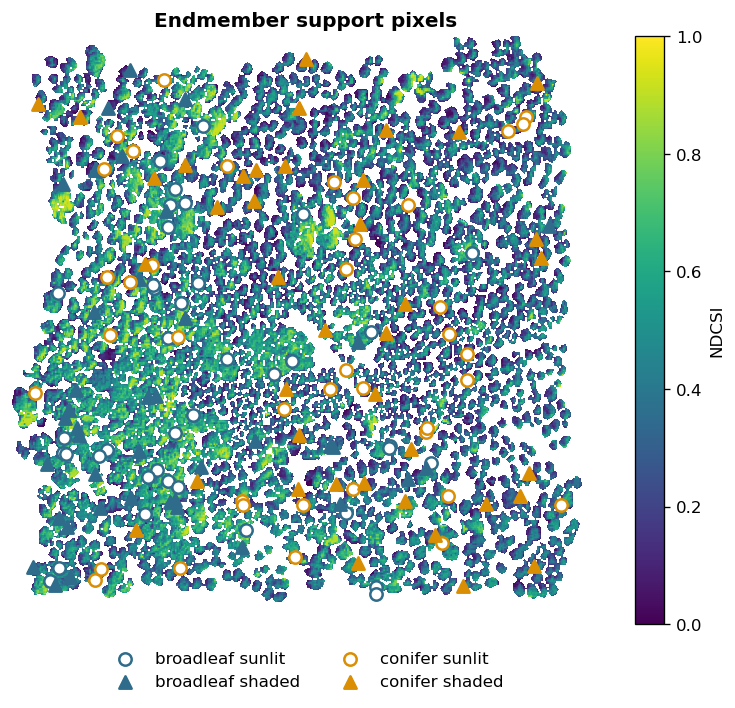

In [13]:
def select_support(candidate_mask, target):
    rows, cols = np.nonzero(candidate_mask)
    values = ndcsi[rows, cols]
    finite = np.isfinite(values)
    rows, cols, values = rows[finite], cols[finite], values[finite]
    order = np.argsort(np.abs(values - target))

    chosen = []
    for row, col, value in zip(rows[order], cols[order], values[order]):
        if any(max(abs(int(row) - r0), abs(int(col) - c0)) <= MIN_SPACING_PIXELS for r0, c0, _ in chosen):
            continue
        chosen.append((int(row), int(col), float(value)))
        if len(chosen) == ENDMEMBER_SUPPORT_SIZE:
            break
    return chosen


if not (0 <= SHADE_PERCENTILES[0] < SHADE_PERCENTILES[1] < SUN_PERCENTILES[0] < SUN_PERCENTILES[1] <= 1):
    raise ValueError("Shade and sun percentile ranges must be ordered and non-overlapping")

support_by_type = {}
for tree_type, mask in tree_masks.items():
    values = ndcsi[mask & np.isfinite(ndcsi)]
    shade_low, shade_high = np.quantile(values, SHADE_PERCENTILES)
    sun_low, sun_high = np.quantile(values, SUN_PERCENTILES)

    shade_pool = mask & np.isfinite(ndcsi) & (ndcsi >= shade_low) & (ndcsi <= shade_high)
    sun_pool = mask & np.isfinite(ndcsi) & (ndcsi >= sun_low) & (ndcsi <= sun_high)
    shade = select_support(shade_pool, np.quantile(values, np.mean(SHADE_PERCENTILES)))
    sun = select_support(sun_pool, np.quantile(values, np.mean(SUN_PERCENTILES)))

    if min(len(shade), len(sun)) < MIN_SUPPORT_REQUIRED:
        raise ValueError(f"Too few support pixels for {tree_type}: shade={len(shade)}, sun={len(sun)}")

    support_by_type[tree_type] = {"shaded": shade, "sunlit": sun}
    print(f"{tree_type}: selected {len(shade)} shaded + {len(sun)} sunlit support pixels")

# Save support pixels for spatial inspection in GIS.
records = []
with rasterio.open(BSQ_PATH) as src:
    for tree_type, support in support_by_type.items():
        for label in ("shaded", "sunlit"):
            for rank, (row, col, value) in enumerate(support[label], 1):
                x, y = rasterio.transform.xy(src.transform, row, col, offset="center")
                records.append({
                    "tree_type": tree_type, "class": label, "rank": rank,
                    "row": row, "col": col, "ndcsi": value,
                    "geometry": Point(float(x), float(y)),
                })
    support_crs = src.crs

support_points = gpd.GeoDataFrame(records, geometry="geometry", crs=support_crs)
gpkg_path = OUT_DIR / "endmember_support_pixels.gpkg"
if gpkg_path.exists():
    gpkg_path.unlink()
support_points.to_file(gpkg_path, layer="endmember_pixels", driver="GPKG")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ndcsi, cmap=MAP_CMAP, vmin=0, vmax=1)
for tree_type, support in support_by_type.items():
    color = TREE_COLORS[tree_type]
    for label, marker, filled in (("sunlit", "o", False), ("shaded", "^", True)):
        pts = support[label]
        ax.scatter(
            [p[1] for p in pts], [p[0] for p in pts], s=55, marker=marker,
            facecolors=color if filled else "white", edgecolors=color, linewidths=1.5,
            label=f"{tree_type} {label}",
        )
ax.set(title="Endmember support pixels")
ax.axis("off")
fig.colorbar(im, ax=ax, label="NDCSI", fraction=0.046, pad=0.04)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "endmember_support_pixels.png", bbox_inches="tight")
plt.show()


## 5. Build shaded and sunlit spectral endmembers

For each tree type, use the median spectrum of the selected support pixels as the shaded or sunlit endmember. Spectra are not normalized before this step.


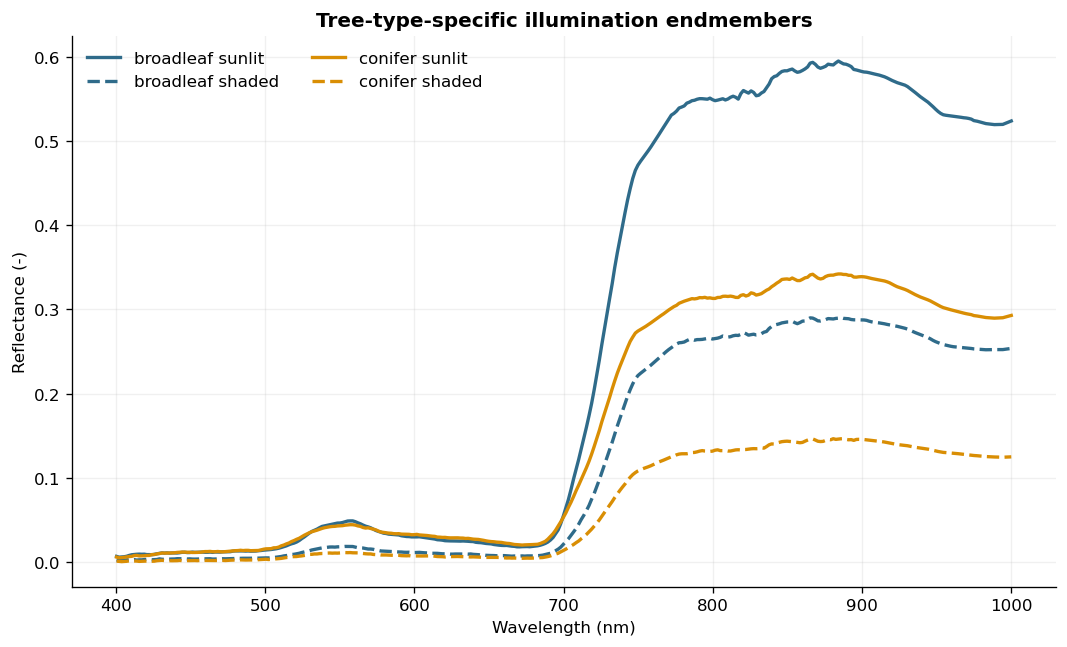

In [14]:
endmembers = {}
npz_data = {"wavelengths": wavelengths.astype("float32")}

for tree_type, support in support_by_type.items():
    endmembers[tree_type] = {}
    for label in ("shaded", "sunlit"):
        rows = [p[0] for p in support[label]]
        cols = [p[1] for p in support[label]]
        median = median_endmember(sample_spectra(rows, cols), f"{tree_type} {label}")
        endmembers[tree_type][label] = median
        npz_data[f"{tree_type}_{label}"] = median

np.savez_compressed(OUT_DIR / "sun_shade_endmembers.npz", **npz_data)

keep = band_indices(wavelengths, UNMIXING_RANGE)
fig, ax = plt.subplots(figsize=(9, 5.5))
for tree_type, spectra in endmembers.items():
    for label, linestyle in (("sunlit", "-"), ("shaded", "--")):
        ax.plot(
            wavelengths[keep], spectra[label][keep],
            color=TREE_COLORS[tree_type], linestyle=linestyle, linewidth=2,
            label=f"{tree_type} {label}",
        )
ax.set(
    title="Tree-type-specific illumination endmembers",
    xlabel="Wavelength (nm)", ylabel="Reflectance (-)",
)
ax.grid(alpha=0.18)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "endmember_spectra.png", bbox_inches="tight")
plt.show()


## 6. Estimate `f_sun` and spectral-fit RMSE

Project every crown spectrum onto its tree-type-specific shaded-to-sunlit mixing line. Values are clipped to `[0, 1]`; RMSE measures the residual spectral mismatch.


In [15]:
def unmixing_band_indices():
    keep = (wavelengths >= UNMIXING_RANGE[0]) & (wavelengths <= UNMIXING_RANGE[1])
    for low, high in EXCLUDE_RANGES:
        keep &= ~((wavelengths >= low) & (wavelengths <= high))
    idx = np.flatnonzero(keep)
    if len(idx) < 2:
        raise ValueError("Too few wavelength bands remain for unmixing")
    return idx


def unmix_tree_type(mask, sun_endmember, shade_endmember):
    band_idx = unmixing_band_indices()
    sun = sun_endmember[band_idx].astype("float64")
    shade = shade_endmember[band_idx].astype("float64")
    finite = np.isfinite(sun) & np.isfinite(shade)
    band_idx, sun, shade = band_idx[finite], sun[finite], shade[finite]

    direction = sun - shade
    denom = float(direction @ direction)
    if len(band_idx) < 2 or not np.isfinite(denom) or denom <= 1e-12:
        raise ValueError("Sunlit and shaded endmembers are spectrally indistinguishable")

    f_local = np.full(raster_shape, np.nan, dtype="float32")
    rmse_local = np.full(raster_shape, np.nan, dtype="float32")

    with rasterio.open(BSQ_PATH) as src:
        raster_bands = (band_idx + 1).tolist()
        for y0 in range(0, raster_shape[0], BLOCK_ROWS):
            y1 = min(raster_shape[0], y0 + BLOCK_ROWS)
            block = scaled_reflectance(
                src.read(raster_bands, window=Window(0, y0, raster_shape[1], y1 - y0)),
                src.nodata,
            ).astype("float64")
            Y = block.reshape(len(band_idx), -1)
            valid = np.all(np.isfinite(Y), axis=0) & mask[y0:y1].ravel()
            if not valid.any():
                continue

            Yv = Y[:, valid]
            f = np.clip(direction @ (Yv - shade[:, None]) / denom, 0, 1)
            prediction = shade[:, None] + direction[:, None] * f
            error = np.sqrt(np.mean((Yv - prediction) ** 2, axis=0))

            block_f = np.full((y1 - y0) * raster_shape[1], np.nan, dtype="float32")
            block_rmse = block_f.copy()
            block_f[valid] = f
            block_rmse[valid] = error
            f_local[y0:y1] = block_f.reshape(y1 - y0, raster_shape[1])
            rmse_local[y0:y1] = block_rmse.reshape(y1 - y0, raster_shape[1])

    return f_local, rmse_local


f_sun = np.full(raster_shape, np.nan, dtype="float32")
rmse = np.full(raster_shape, np.nan, dtype="float32")
f_sun_by_type = {}

for tree_type, mask in tree_masks.items():
    local_f, local_rmse = unmix_tree_type(
        mask, endmembers[tree_type]["sunlit"], endmembers[tree_type]["shaded"]
    )
    f_sun_by_type[tree_type] = local_f
    f_sun[mask] = local_f[mask]
    rmse[mask] = local_rmse[mask]

    valid = mask & np.isfinite(local_f)
    print(
        f"{tree_type}: median f_sun={np.nanmedian(local_f[valid]):.3f} | "
        f"median RMSE={np.nanmedian(local_rmse[valid]):.5f} | "
        f"clipped 0/1={100*np.mean(local_f[valid] <= 1e-6):.1f}% / "
        f"{100*np.mean(local_f[valid] >= 1-1e-6):.1f}%"
    )

# Explicit tree-type arrays requested in addition to the combined f_sun map.
f_sun_broadleaf = f_sun_by_type["broadleaf"]
f_sun_conifer = f_sun_by_type["conifer"]

output_paths = {
    "f_sun": write_tif("f_sun.tif", f_sun, "tree-type-specific spectral sunlit mixing coordinate"),
    "f_sun_broadleaf": write_tif("f_sun_broadleaf.tif", f_sun_broadleaf, "broadleaf spectral sunlit mixing coordinate"),
    "f_sun_conifer": write_tif("f_sun_conifer.tif", f_sun_conifer, "conifer spectral sunlit mixing coordinate"),
    "rmse": write_tif("rmse.tif", rmse, "tree-type-specific two-endmember spectral-fit RMSE"),
}
for name, path in output_paths.items():
    print(f"Saved {name}: {path}")


broadleaf: median f_sun=0.604 | median RMSE=0.00761 | clipped 0/1=15.2% / 16.0%
conifer: median f_sun=0.472 | median RMSE=0.00483 | clipped 0/1=15.5% / 15.6%
Saved f_sun: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade_unmixing_by_tree_types\f_sun.tif
Saved f_sun_broadleaf: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade_unmixing_by_tree_types\f_sun_broadleaf.tif
Saved f_sun_conifer: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade_unmixing_by_tree_types\f_sun_conifer.tif
Saved rmse: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade_unmixing_by_tree_types\rmse.tif


## 7. Inspect the main results

Compare NDCSI, `f_sun`, and RMSE. Similar NDCSI/`f_sun` spatial patterns are expected; high RMSE indicates spectra that are poorly represented by the simple two-endmember line. This is a model diagnostic, not independent physical validation.


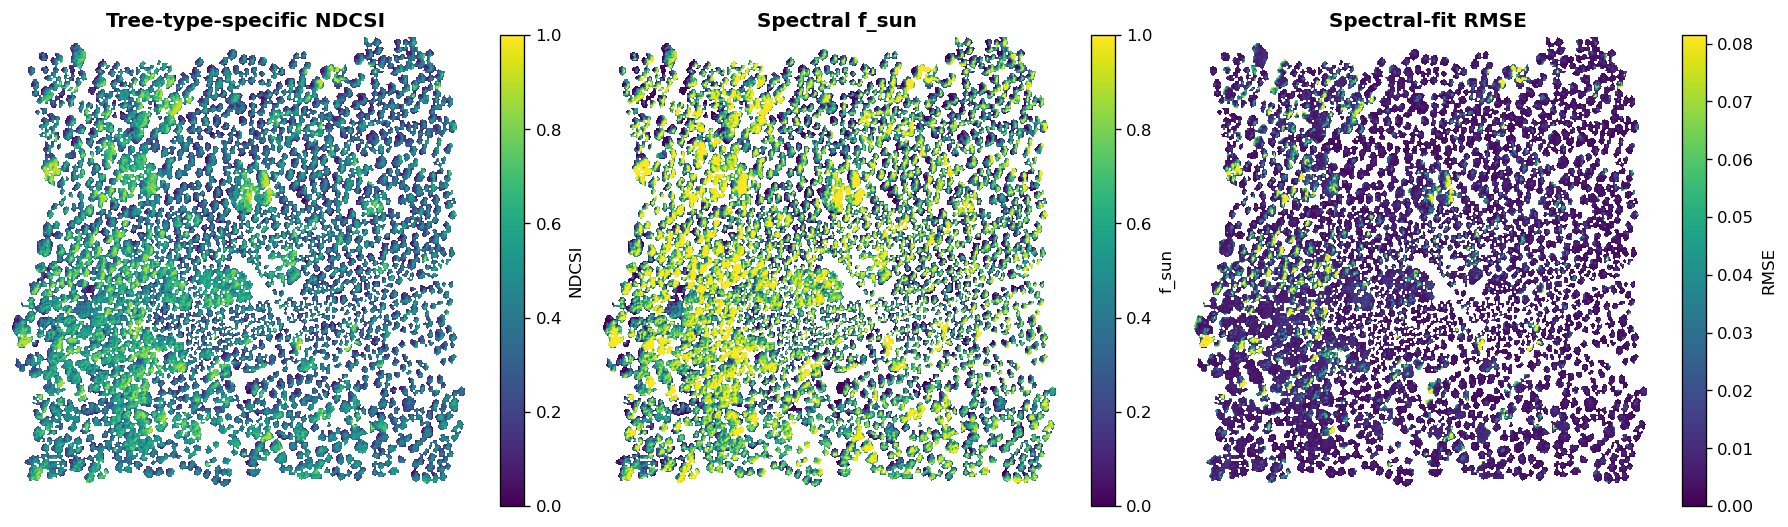

In [16]:
rmse_max = (
    np.nanpercentile(rmse, 98)
    if RMSE_DISPLAY_MAX is None and np.isfinite(rmse).any()
    else (RMSE_DISPLAY_MAX if RMSE_DISPLAY_MAX is not None else 1.0)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
plots = [
    (ndcsi, "Tree-type-specific NDCSI", 0, 1, "NDCSI"),
    (f_sun, "Spectral f_sun", 0, 1, "f_sun"),
    (rmse, "Spectral-fit RMSE", 0, rmse_max, "RMSE"),
]
for ax, (data, title, vmin, vmax, label) in zip(axes, plots):
    im = ax.imshow(data, cmap=MAP_CMAP, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, label=label, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(OUT_DIR / "illumination_diagnostics.png", bbox_inches="tight")
plt.show()
